# 01 · Data and EDA

Inputs: seven Aqua-MODIS **Level-3 mapped** (`L3m`) monthly-climatology products, 9 km, regridded to 1°. Targets: WOA13 v2 objectively analysed surface nitrate, phosphate and silicate, 1°. The file holds all twelve months; the maps below show January (the month used in `02_results.ipynb`) and July. Sources and the build step are in `data/README.md` and `00_download_and_build.ipynb`.

In [1]:
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap, LogNorm

from modis_nutrients.config import load_config
from modis_nutrients.dataset import TableSpec, grid_to_table, load_grid, spec_from_config

cfg = load_config()
ds = load_grid(cfg["data"]["path"])
MONTHS = [1, 7]
ds

<xarray.Dataset> Size: 68MB
Dimensions:       (month: 12, lat: 180, lon: 360)
Coordinates:
  * month         (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat           (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon           (lon) float32 1kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables: (12/19)
    CHL           (month, lat, lon) float32 3MB ...
    APH           (month, lat, lon) float32 3MB ...
    FLU           (month, lat, lon) float32 3MB ...
    PIC           (month, lat, lon) float32 3MB ...
    POC           (month, lat, lon) float32 3MB ...
    PAR           (month, lat, lon) float32 3MB ...
    ...            ...
    phosphate_dd  (month, lat, lon) float64 6MB ...
    phosphate_se  (month, lat, lon) float32 3MB ...
    silicate      (month, lat, lon) float32 3MB ...
    silicate_mn   (month, lat, lon) float32 3MB ...
    silicate_dd   (month, lat, lon) float64 6MB ...
    silicate_se   (month, lat, lon) float32 3MB ...
Attributes:
    source:                   Aqua-MODIS L3m monthly climatology, 9 km, area-...
    geometric_mean_products:  CHL,APH,PIC,POC
    description:              MODIS ocean-colour products (area-mean to 1 deg...

## Usable cells

One row per 1° ocean cell with all seven inputs and all three targets. `spec_from_config` follows `data.months` in the config (January).

In [2]:
spec = spec_from_config(cfg)
df = grid_to_table(ds, spec)
print(f"{len(df)} usable cells in months {df.attrs['months']}")
df[[*spec.features, *spec.targets]].agg(["count", "min", "median", "max"]).T.round(3)

33412 usable cells in months [1]


,count,min,median,max
CHL,33412.0,0.008,0.159,14.963
APH,33412.0,0.002,0.013,0.641
FLU,33412.0,0.014,0.081,1.384
PIC,33412.0,0.000,0.000,0.097
POC,33412.0,17.281,55.187,1947.039
PAR,33412.0,3.887,42.243,64.393
SST,33412.0,-1.027,20.838,31.332
nitrate,33412.0,0.000,1.020,33.715
phosphate,33412.0,0.000,0.306,2.606
silicate,33412.0,0.000,2.552,97.694


## Maps of inputs and targets

Log colour scales for CHL, APH, PIC and POC, which span orders of magnitude. January and July.

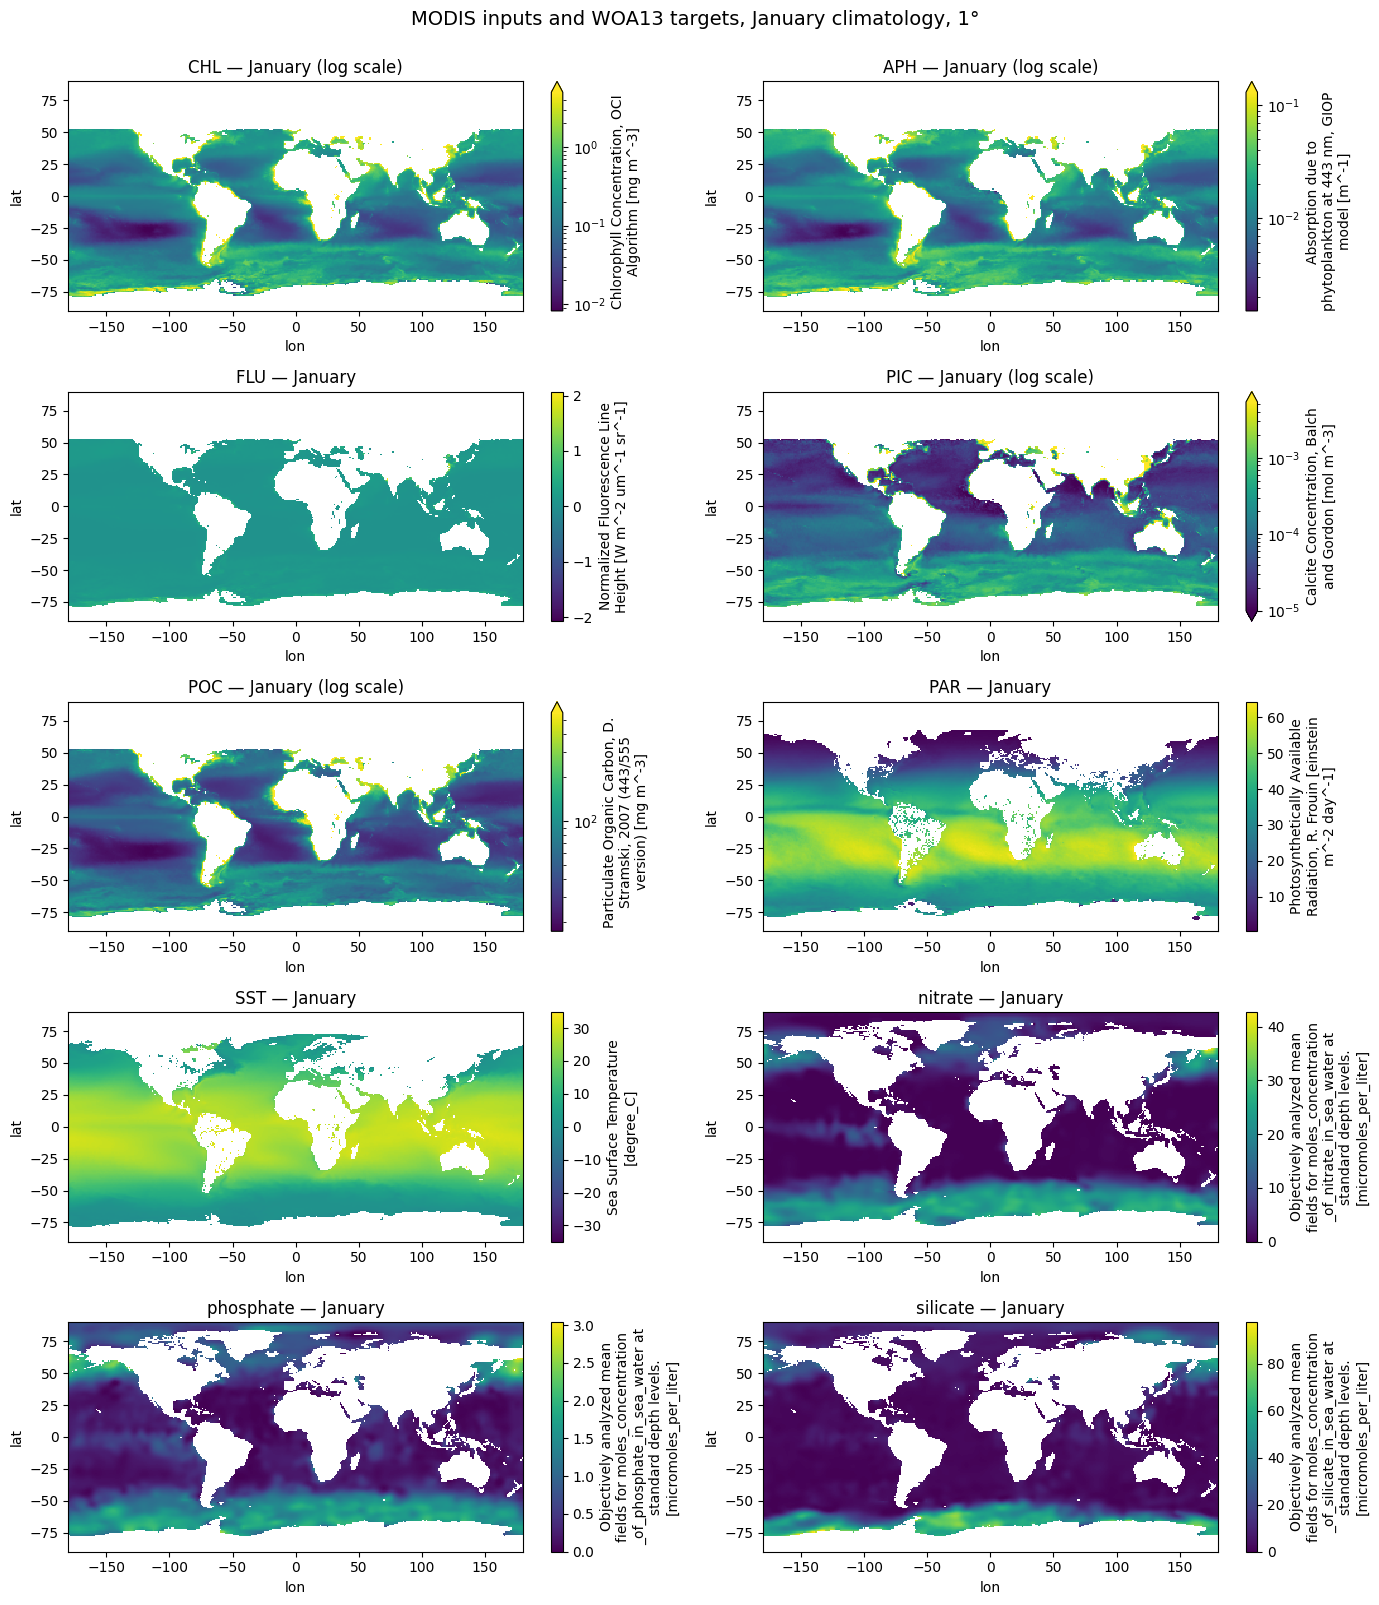

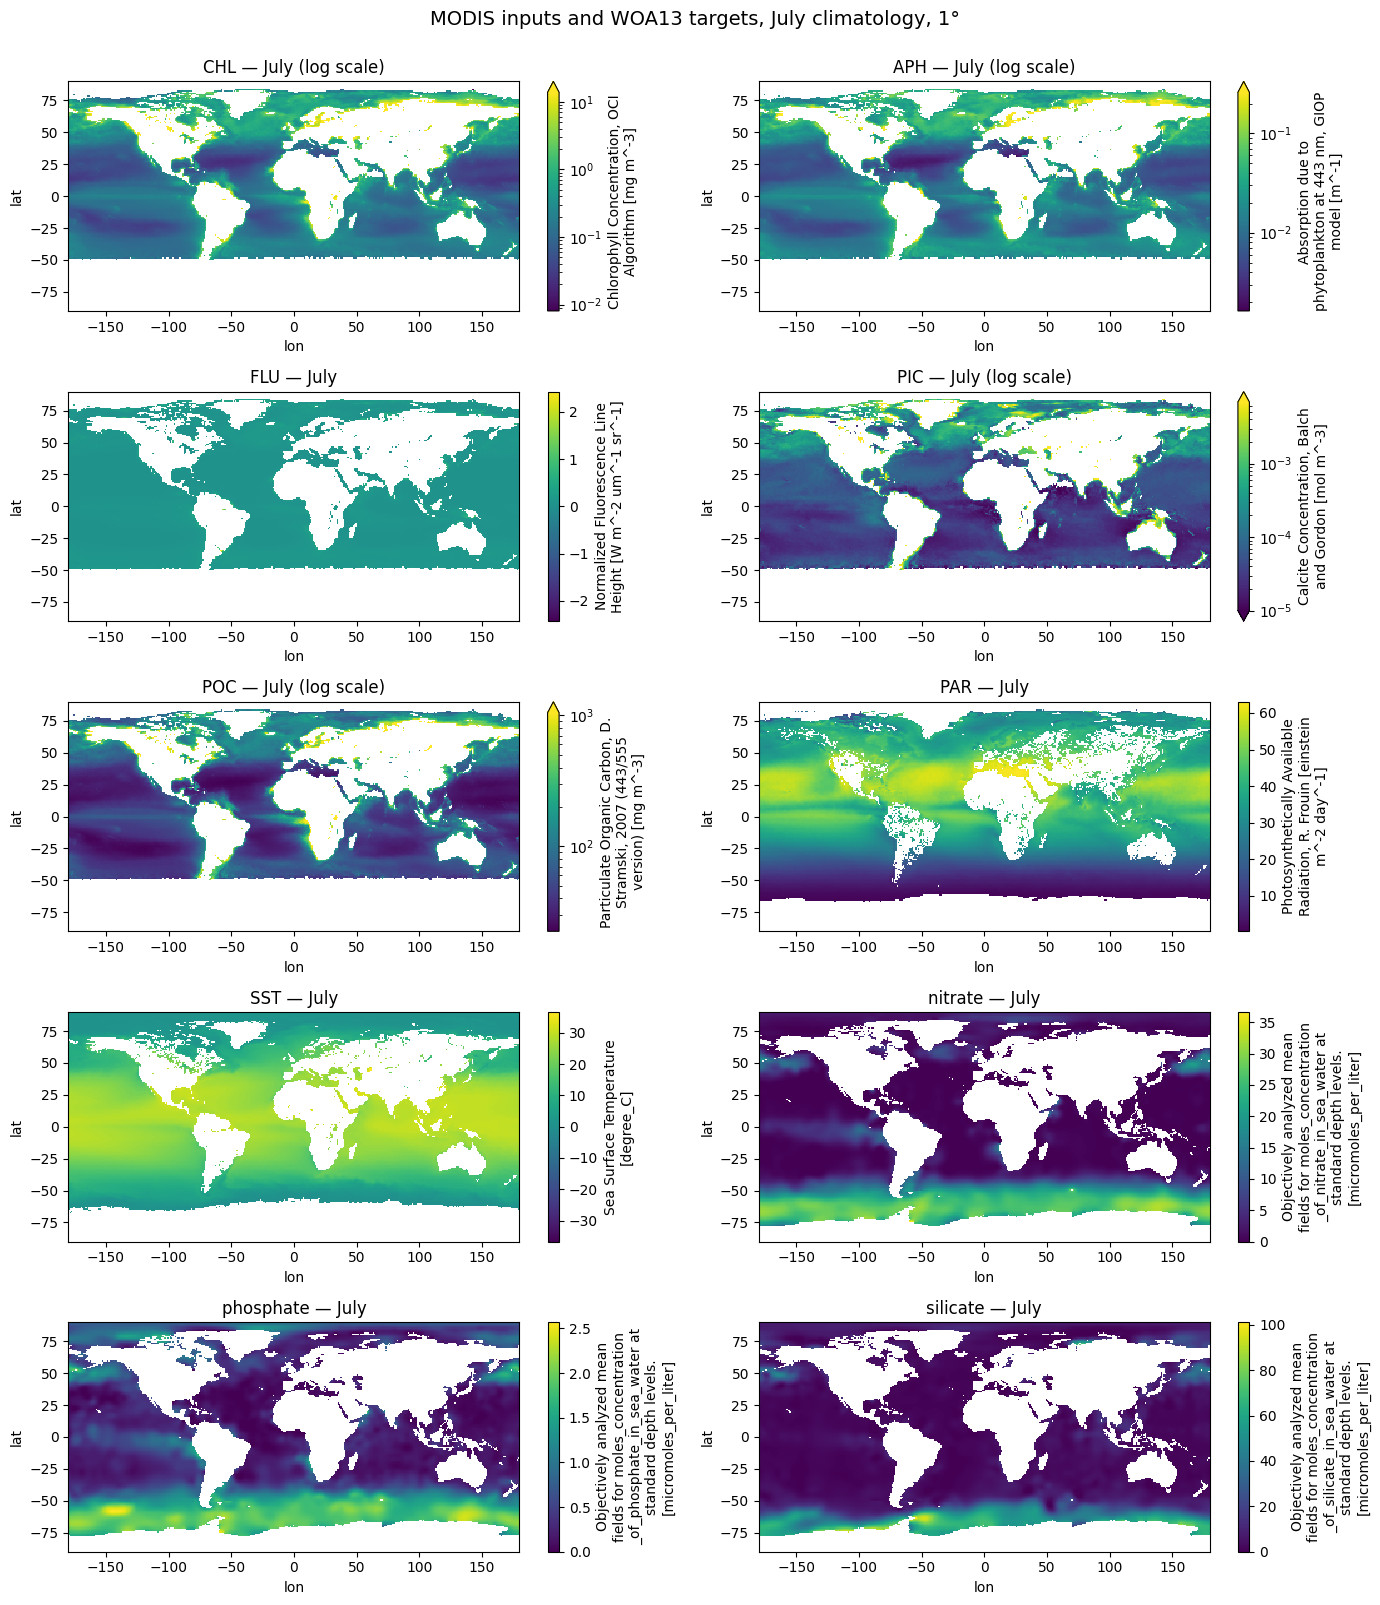

In [3]:
cols = [*spec.features, *spec.targets]
for m in MONTHS:
    fig, axes = plt.subplots(5, 2, figsize=(14, 16))
    for ax, c in zip(axes.ravel(), cols):
        da = ds[c].sel(month=m)
        is_log = c in cfg["data"]["log_features"]
        kw = dict(norm=LogNorm(vmin=max(float(da.min()), 1e-5), vmax=float(da.quantile(0.995)))) if is_log else {}
        da.plot(ax=ax, cmap="viridis", add_colorbar=True, **kw)
        ax.set_title(f"{c} — {calendar.month_name[m]}" + (" (log scale)" if is_log else ""))
    fig.suptitle(f"MODIS inputs and WOA13 targets, {calendar.month_name[m]} climatology, 1°", fontsize=14, y=1.0)
    plt.tight_layout()
    plt.show()

## Coverage

Where MODIS and WOA are both available. MODIS has no data in the winter hemisphere's high latitudes (polar night and low sun): north of about 52°N in January, south of about 50°S in July. WOA covers the whole ocean, including inland seas such as the Caspian.

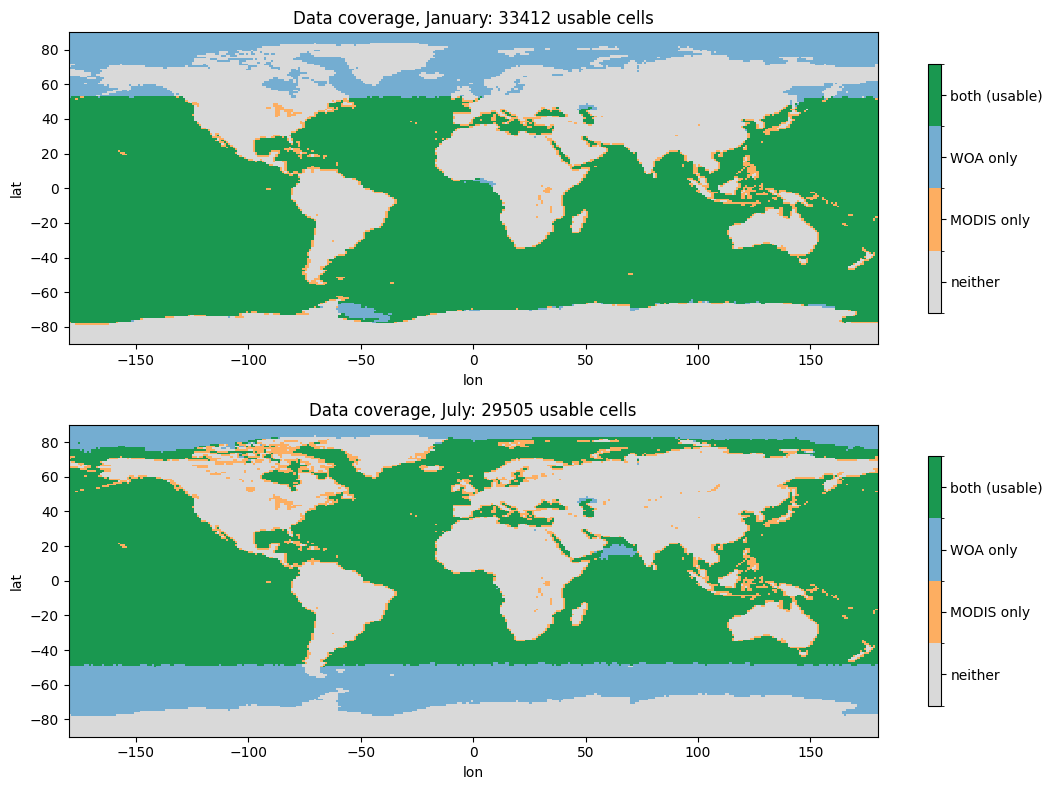

In [4]:
cmap = ListedColormap(["#d9d9d9", "#fdae61", "#74add1", "#1a9850"])   # neither, MODIS only, WOA only, both
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, axes = plt.subplots(len(MONTHS), 1, figsize=(11, 4 * len(MONTHS)))
for ax, m in zip(axes, MONTHS):
    feat_ok = ds[spec.features].sel(month=m).to_array().notnull().all("variable")
    targ_ok = ds[spec.targets].sel(month=m).to_array().notnull().all("variable")
    cov = feat_ok.astype(int) + 2 * targ_ok.astype(int)
    p = cov.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=True, cbar_kwargs={"ticks": [0, 1, 2, 3], "shrink": 0.8})
    p.colorbar.set_ticklabels(["neither", "MODIS only", "WOA only", "both (usable)"])
    n_usable = int((feat_ok & targ_ok).sum())
    ax.set_title(f"Data coverage, {calendar.month_name[m]}: {n_usable} usable cells")
plt.tight_layout()
plt.show()

## Correlations

Pearson correlation on usable cells (log10 for CHL, APH, PIC, POC): January only, and all twelve months pooled. Pooling weakens the SST–nutrient correlation slightly and the ocean-colour–nutrient correlations substantially, because the relationship between phytoplankton signals and nutrients changes with season (a spring bloom is high chlorophyll while nutrients are being drawn down).

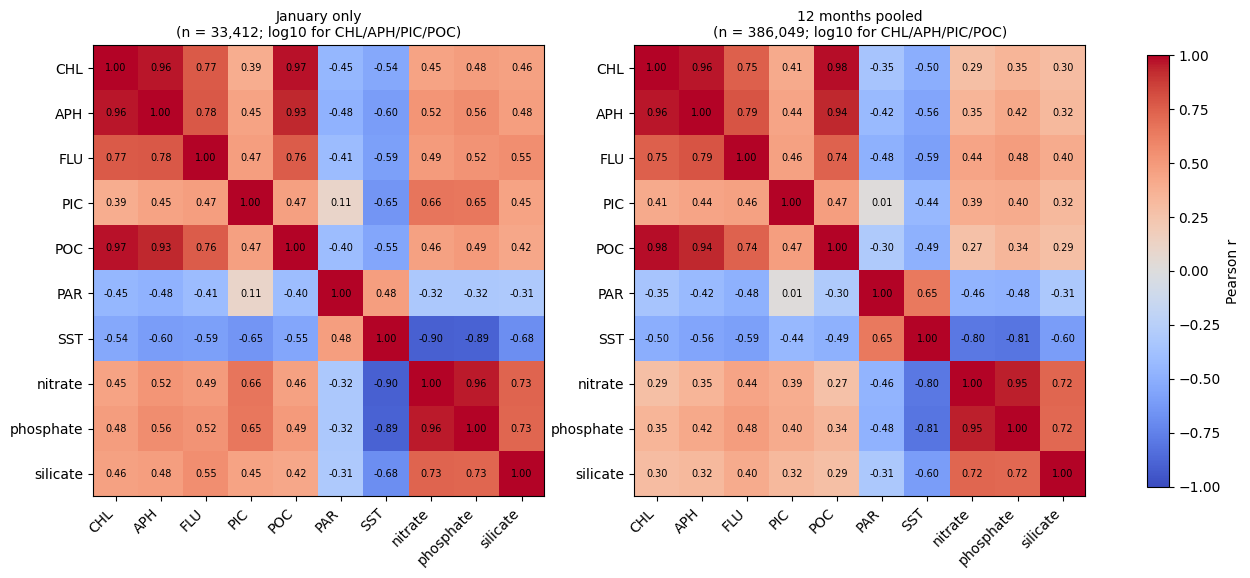

In [5]:
def plot_corr(df, title, ax):
    X = df[[*spec.features, *spec.targets]].copy()
    for c in cfg["data"]["log_features"]:
        X[c] = np.log10(X[c].clip(lower=1e-6))
    corr = X.corr()
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"{title}\n(n = {len(df):,}; log10 for CHL/APH/PIC/POC)", fontsize=10)
    return im

df_all = grid_to_table(ds, TableSpec(spec.features, spec.targets))   # months=None -> all twelve
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_corr(df, f"{calendar.month_name[spec.months[0]]} only", axes[0])
im = plot_corr(df_all, "12 months pooled", axes[1])
fig.colorbar(im, ax=axes, shrink=0.8, label="Pearson r")
plt.show()

SST is strongly anti-correlated with all three nutrients (stratification / upwelling). The ocean-colour products are mutually correlated (CHL, APH, POC, FLU all track phytoplankton biomass), which matters for interpretation: SHAP values will be spread across correlated inputs.